<a href="https://colab.research.google.com/github/YakoYakoko/Estudios/blob/main/ConceptosRegresion_Ridge_y_Lasso.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
library(dplyr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




# Introducción
La **regresión Ridge** y la **regresión Lasso** son técnicas de regularización que se utilizan en modelos de regresión lineal para mejorar la generalización y manejar problemas de sobreajuste (overfitting). Ambas técnicas añaden una penalización a la función de pérdida de la regresión lineal, pero lo hacen de maneras distintas y tienen propiedades y aplicaciones específicas.

#1. Regresión Ridge

También conocida como regresión de cresta, tiene como objetivo reducir el sobreajuste al penalizar los coeficientes de regresión grandes. Esto se logra añadiendo una penalización basada en la magnitud de los coeficientes al término de error del modelo.

**Función Objetivo:**

La función objetivo de la regresión Ridge es minimizar la siguiente expresión:

$Costo = \| \mathbf{y} - \mathbf{X} \boldsymbol{\beta} \|^2 + \lambda \| \boldsymbol{\beta} \|^2_2 $

donde:
$\| \mathbf{y} - \mathbf{X} \boldsymbol{\beta} \|^2$ es el término de error residual (suma de los cuadrados de las diferencias entre los valores observados y predichos).

$\lambda \| \boldsymbol{\beta} \|^2_2$ es el término de penalización (donde $\lambda$ es el parámetro de regularización y $\| \boldsymbol{\beta} \|^2_2$ es la norma $L_2$ de los coeficientes $\boldsymbol{\beta}$).

**Características:**
- **Penalización $L_2$**: La penalización es la suma de los cuadrados de todos los coeficientes. Esto tiende a reducir los coeficientes grandes, pero no los lleva a cero.
- **Efecto en los coeficientes**: Los coeficientes son penalizados de manera que se acercan a cero, pero no exactamente a cero, lo que significa que la regresión Ridge tiende a mantener todos los predictores en el modelo.

**Uso típico:**
- Es útil cuando se sospecha que todos los predictores tienen alguna relación con la variable dependiente y no se desea excluir ninguno de ellos.
- Se usa cuando hay multicolinealidad (correlación alta entre predictores).


### 2. Regresión Lasso

**Objetivo:**
La regresión Lasso (Least Absolute Shrinkage and Selection Operator) también busca reducir el sobreajuste y mejorar la generalización del modelo, pero lo hace de manera diferente a la regresión Ridge. Además de penalizar la magnitud de los coeficientes, el Lasso tiene la capacidad de reducir algunos coeficientes exactamente a cero, lo que lleva a una selección de características.

**Función Objetivo:**
La función objetivo de la regresión Lasso es minimizar:
$ \text{Costo} = \| \mathbf{y} - \mathbf{X} \boldsymbol{\beta} \|^2 + \lambda \| \boldsymbol{\beta} \|_1 $

donde:
- $\| \mathbf{y} - \mathbf{X} \boldsymbol{\beta} \|^2$ es el término de error residual.
- $\lambda \| \boldsymbol{\beta} \|_1$ es el término de penalización (donde $\lambda$ es el parámetro de regularización y $\| \boldsymbol{\beta} \|_1$ es la norma $L_1$ de los coeficientes $\boldsymbol{\beta}$).

**Características:**
- **Penalización $L_1$**: La penalización es la suma de los valores absolutos de los coeficientes. Esto puede llevar a algunos coeficientes a ser exactamente cero, efectivamente eliminando esos predictores del modelo.
- **Efecto en los coeficientes**: Algunos coeficientes se vuelven exactamente cero, lo que realiza una selección de características.

**Uso típico:**
- Es útil cuando se quiere realizar selección de características además de la regularización.
- Se prefiere cuando se cree que solo un subconjunto de los predictores es relevante para el modelo.

En un conjunto de datos que contenga una gran cantidad de variables es muy importante **identificar cuáles de ellas son predictores significativos** para la variable de respuesta.

Existen diferentes estrategias para identificar predictores significativos. En esta sección analizaremos un par de ellas llamadas:

* Regresión Ridge
* Regresión Lasso

**La gran ventaja de estas opciones es que para su aplicación no es necesario que los datos se ajusten al modelo generativo.**

Revisemos un par de casos

## Caso 1

Considera el siguiente conjunto de datos, cuya descripción puedes encontrar en:

https://web.stanford.edu/~hastie/ElemStatLearn/data.html



In [12]:
d <- read.csv("prostate.data.csv", sep = "\t")
d <- d %>% select(-train, -X) #elimnamos la columna que indica si la observación pertenece al conjunto de entrenamiento
head(d)

,lcavol,lweight,age,lbph,svi,lcp,gleason,pgg45,lpsa
,<dbl>,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>,<int>,<dbl>
1,-0.5798185,2.769459,50,-1.386294,0,-1.386294,6,0,-0.4307829
2,-0.9942523,3.319626,58,-1.386294,0,-1.386294,6,0,-0.1625189
3,-0.5108256,2.691243,74,-1.386294,0,-1.386294,7,20,-0.1625189
4,-1.2039728,3.282789,58,-1.386294,0,-1.386294,6,0,-0.1625189
5,0.7514161,3.432373,62,-1.386294,0,-1.386294,6,0,0.3715636
6,-1.0498221,3.228826,50,-1.386294,0,-1.386294,6,0,0.7654678


El objetivo del estudio es predecir el valor de $\texttt{lpsa}$ a partir del resto de las variables (predictores)

Si ajustamos un modelo lineal y analizamos los resultados, observamos que no todas las variables son predictores significativos.

In [13]:
r <- lm(lpsa~., data = d) #lpsa en función del resto de las variables
summary(r)


Call:
lm(formula = lpsa ~ ., data = d)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.76644 -0.35510 -0.00328  0.38087  1.55770 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.181561   1.320568   0.137  0.89096    
lcavol       0.564341   0.087833   6.425 6.55e-09 ***
lweight      0.622020   0.200897   3.096  0.00263 ** 
age         -0.021248   0.011084  -1.917  0.05848 .  
lbph         0.096713   0.057913   1.670  0.09848 .  
svi          0.761673   0.241176   3.158  0.00218 ** 
lcp         -0.106051   0.089868  -1.180  0.24115    
gleason      0.049228   0.155341   0.317  0.75207    
pgg45        0.004458   0.004365   1.021  0.31000    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.6995 on 88 degrees of freedom
Multiple R-squared:  0.6634,	Adjusted R-squared:  0.6328 
F-statistic: 21.68 on 8 and 88 DF,  p-value: < 2.2e-16


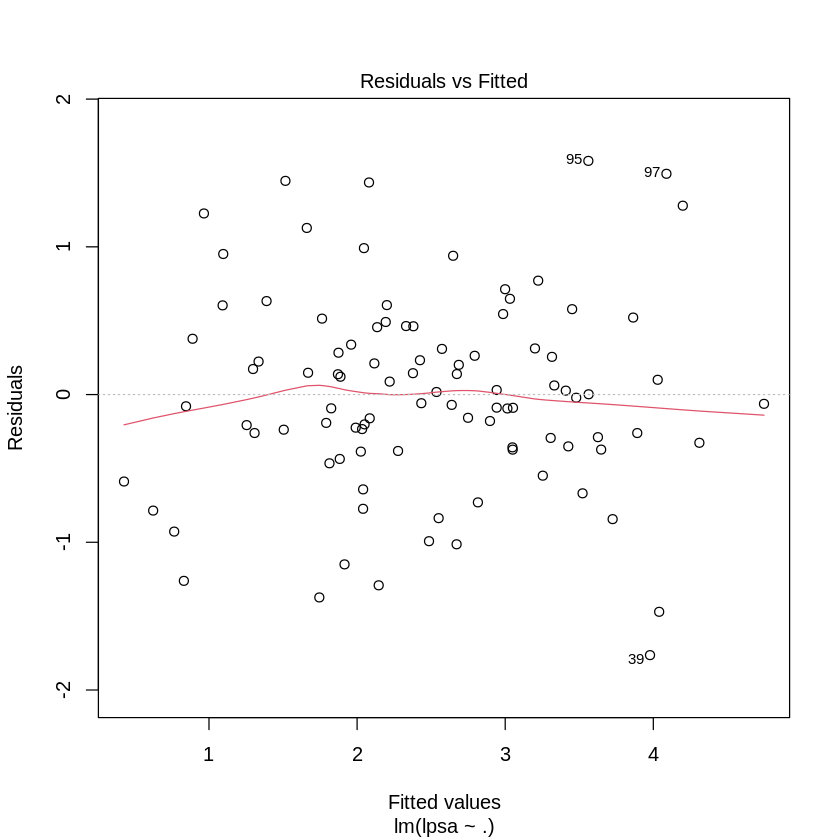

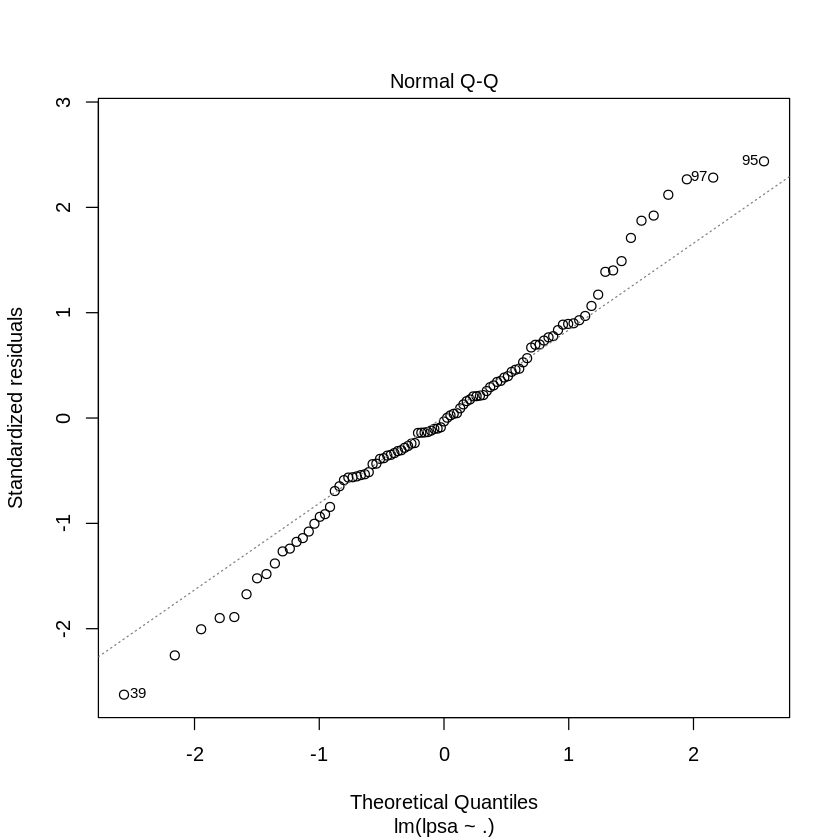

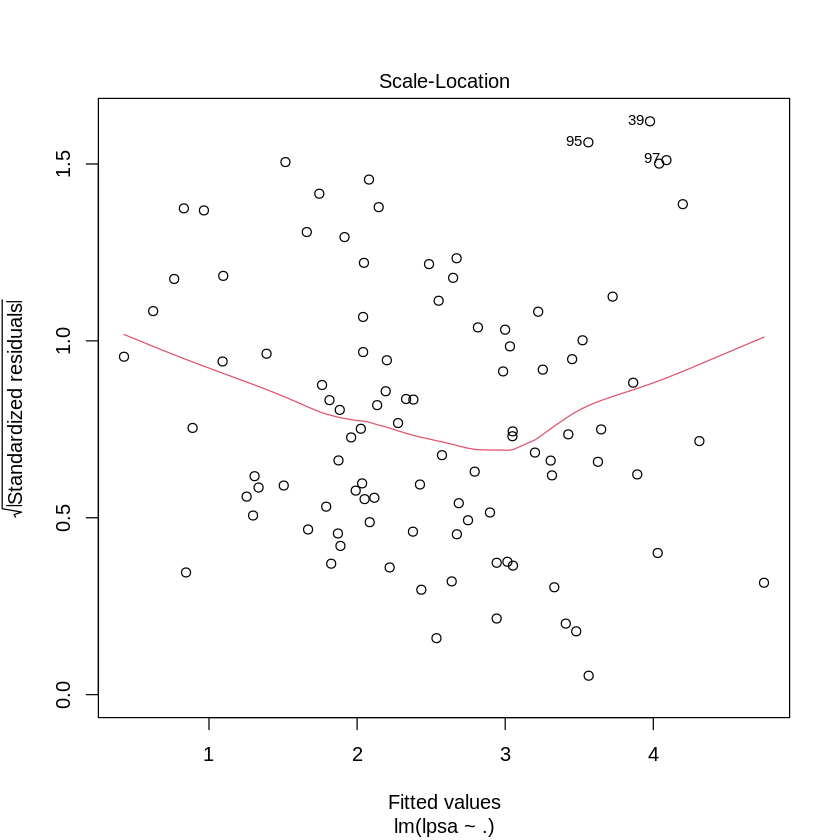

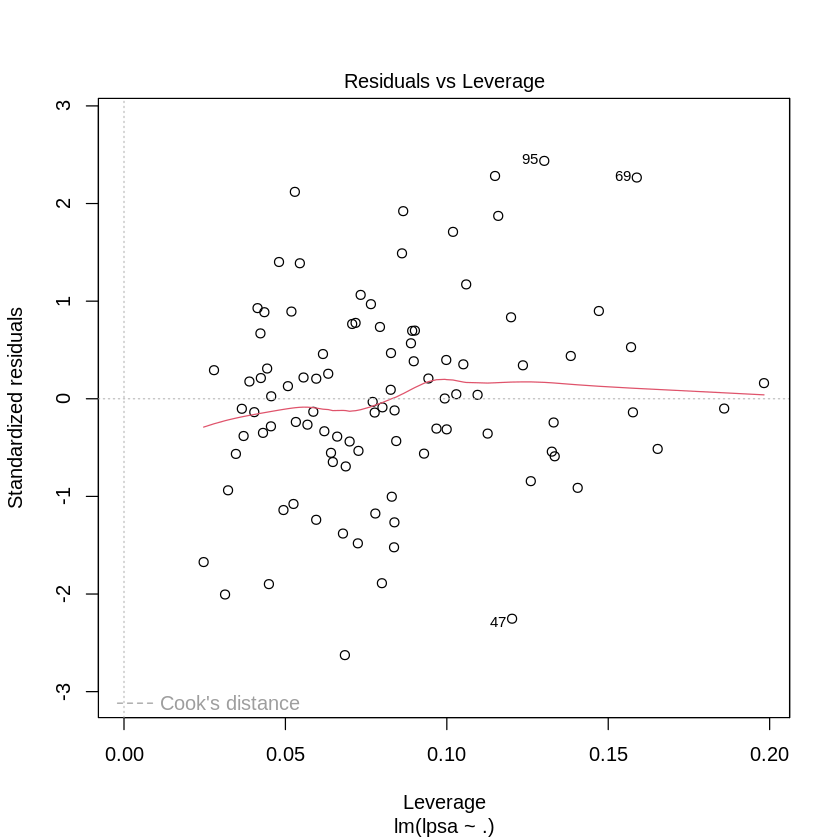

In [ ]:
plot(r)

Una estrategia para construir un modelo más parsimonioso es eliminar, **uno a uno**, los predictores que no sean significativos.

Por ejemplo, eliminamos la variable $\texttt{gleason}$ ya que tiene el mayor p-valor y reajustamos un modelo lineal.

In [14]:
d <- d %>% select(-gleason)
r <- lm(lpsa~., data = d) #lpsa en función del resto de las variables
summary(r)


Call:
lm(formula = lpsa ~ ., data = d)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.76395 -0.35764 -0.02143  0.37762  1.58178 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.494155   0.873567   0.566  0.57304    
lcavol       0.569546   0.085847   6.634 2.46e-09 ***
lweight      0.614420   0.198449   3.096  0.00262 ** 
age         -0.020913   0.010978  -1.905  0.06000 .  
lbph         0.097353   0.057584   1.691  0.09441 .  
svi          0.752397   0.238180   3.159  0.00216 ** 
lcp         -0.104959   0.089347  -1.175  0.24323    
pgg45        0.005324   0.003385   1.573  0.11923    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.696 on 89 degrees of freedom
Multiple R-squared:  0.663,	Adjusted R-squared:  0.6365 
F-statistic: 25.01 on 7 and 89 DF,  p-value: < 2.2e-16


Eliminamos ahora la variable $\texttt{lcp}$

In [15]:
d <- d %>% select(-lcp)
r <- lm(lpsa~., data = d) #lpsa en función del resto de las variables
summary(r)


Call:
lm(formula = lpsa ~ ., data = d)

Residuals:
    Min      1Q  Median      3Q     Max 
-1.8101 -0.3492 -0.0418  0.3968  1.4612 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.521470   0.875099   0.596  0.55274    
lcavol       0.523498   0.076537   6.840 9.28e-10 ***
lweight      0.615235   0.198867   3.094  0.00263 ** 
age         -0.019034   0.010883  -1.749  0.08371 .  
lbph         0.095491   0.057684   1.655  0.10132    
svi          0.635864   0.216996   2.930  0.00429 ** 
pgg45        0.003525   0.003024   1.165  0.24690    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.6974 on 90 degrees of freedom
Multiple R-squared:  0.6578,	Adjusted R-squared:  0.635 
F-statistic: 28.83 on 6 and 90 DF,  p-value: < 2.2e-16


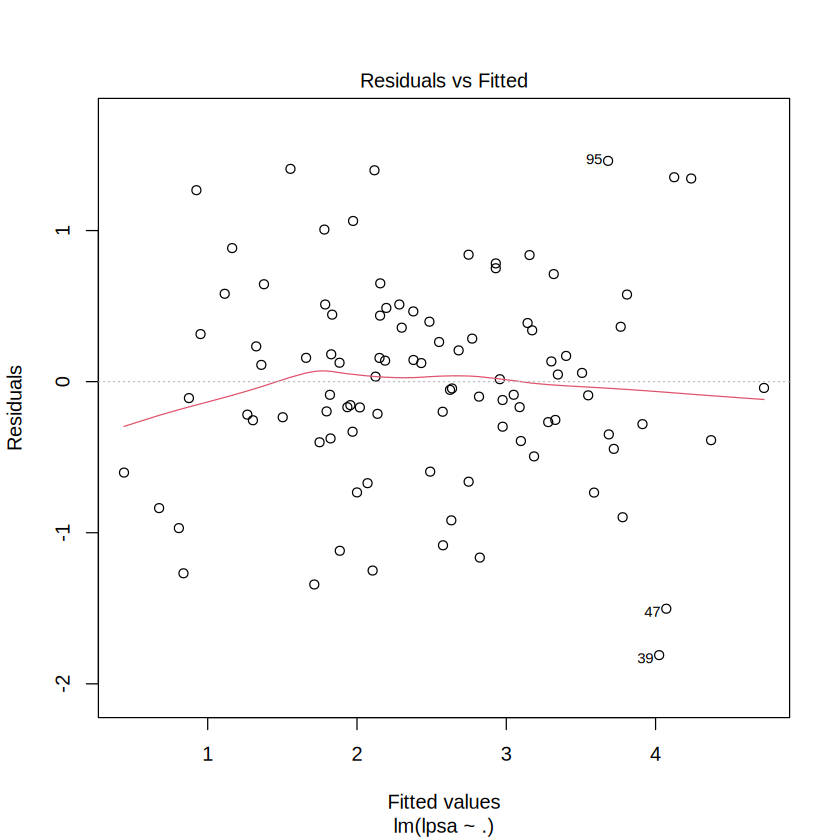

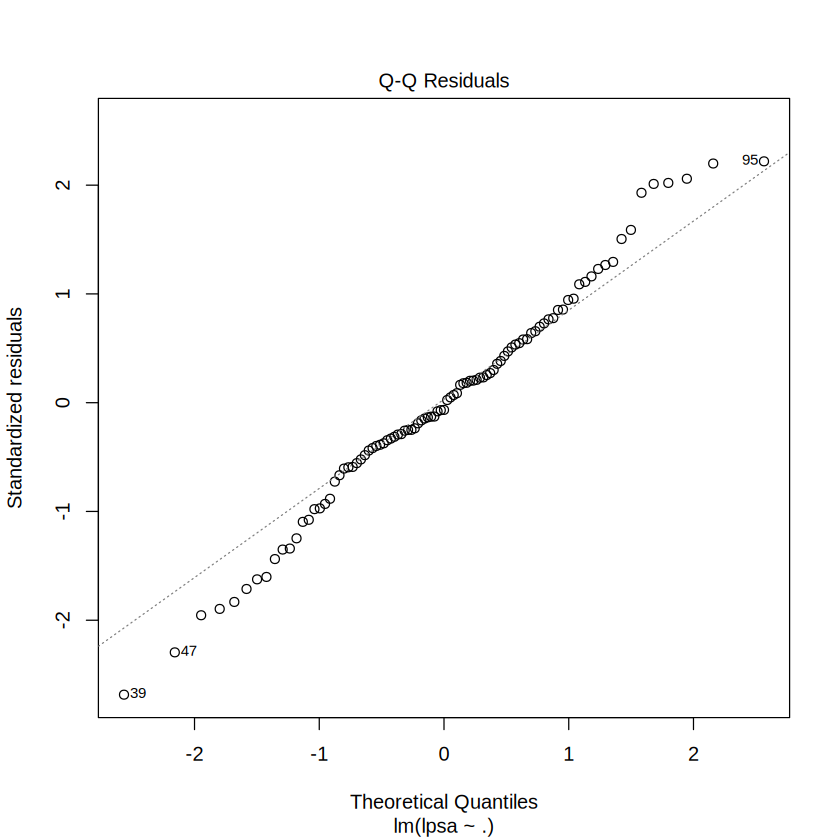

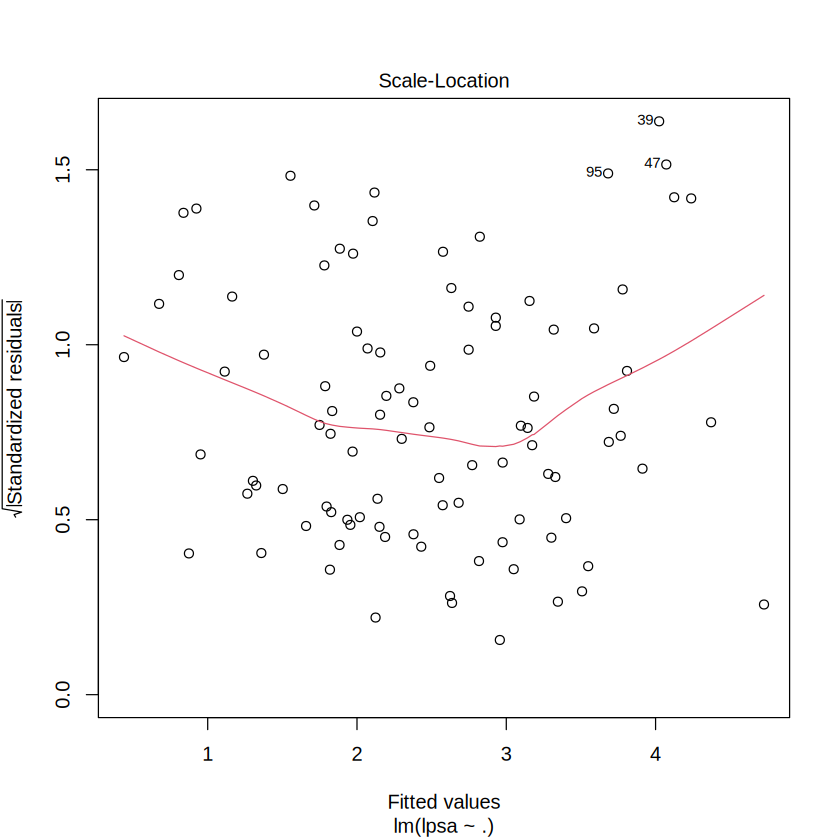

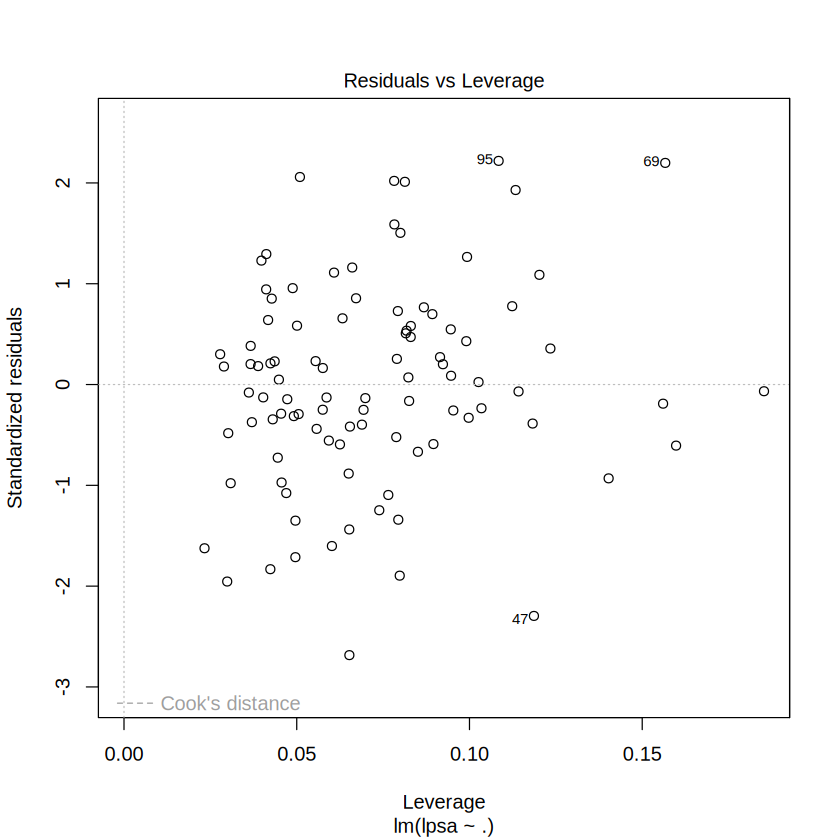

In [17]:
plot(r)

Ahora es el turno de eliminar la variable $\texttt{pgg45}$

In [18]:
d <- d %>% select(-pgg45)
r <- lm(lpsa~., data = d) #lpsa en función del resto de las variables
summary(r)


Call:
lm(formula = lpsa ~ ., data = d)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.86717 -0.37725  0.01257  0.40252  1.44544 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.49473    0.87652   0.564  0.57385    
lcavol       0.54400    0.07463   7.289 1.11e-10 ***
lweight      0.58821    0.19790   2.972  0.00378 ** 
age         -0.01644    0.01068  -1.540  0.12692    
lbph         0.10122    0.05759   1.758  0.08215 .  
svi          0.71490    0.20653   3.461  0.00082 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.6988 on 91 degrees of freedom
Multiple R-squared:  0.6526,	Adjusted R-squared:  0.6335 
F-statistic: 34.19 on 5 and 91 DF,  p-value: < 2.2e-16


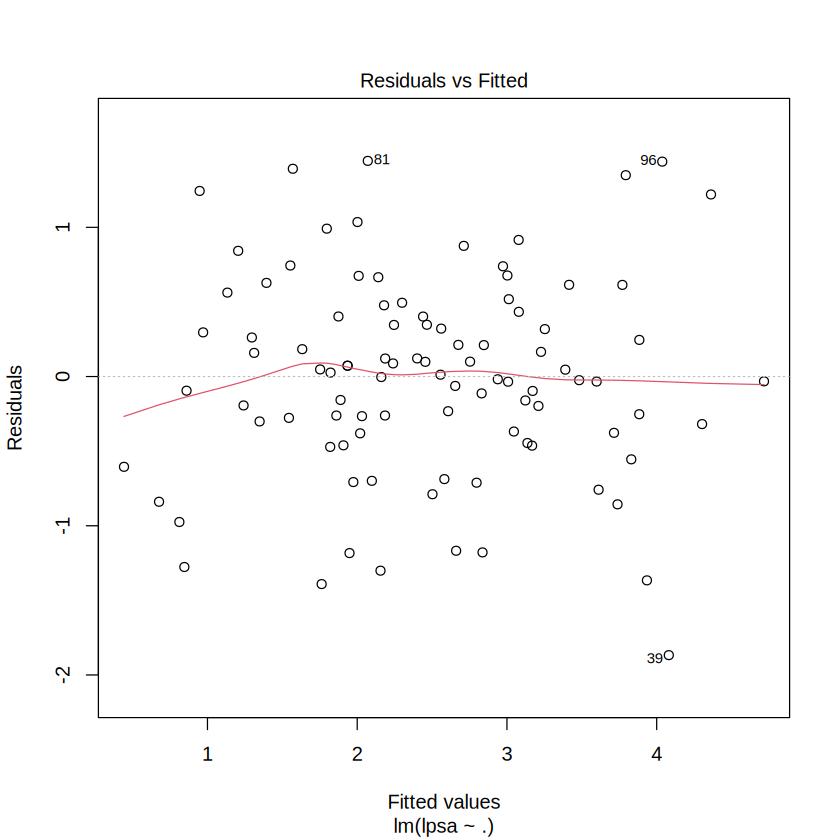

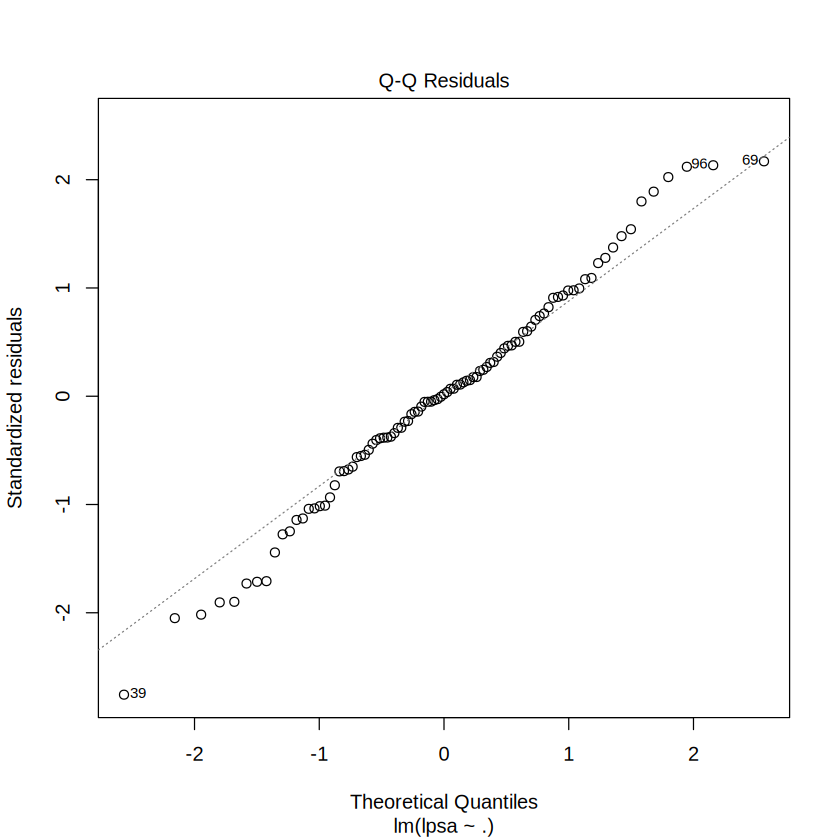

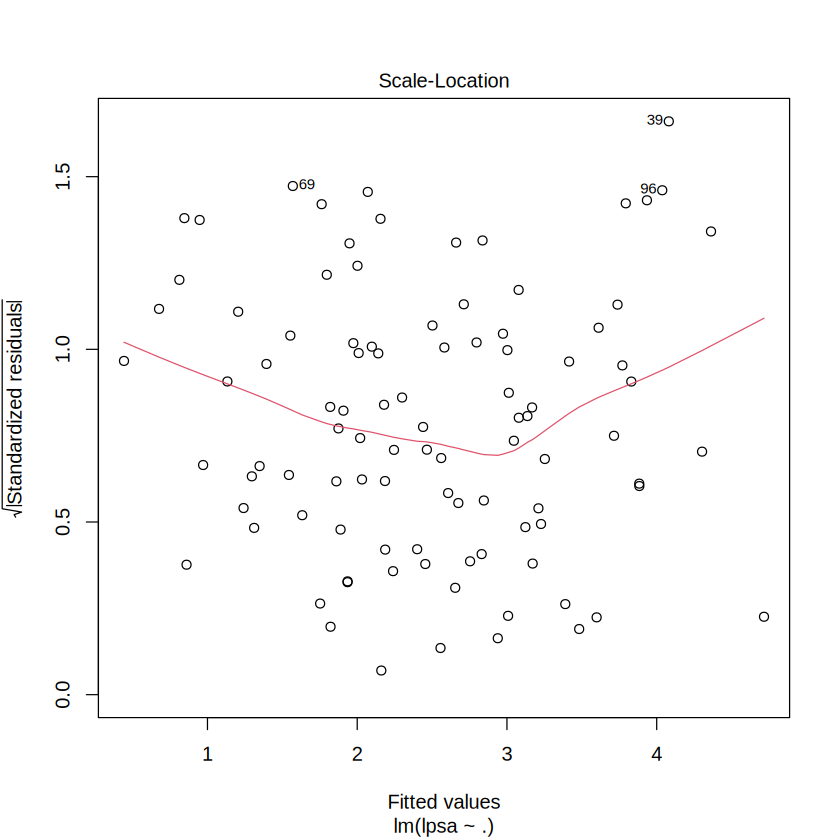

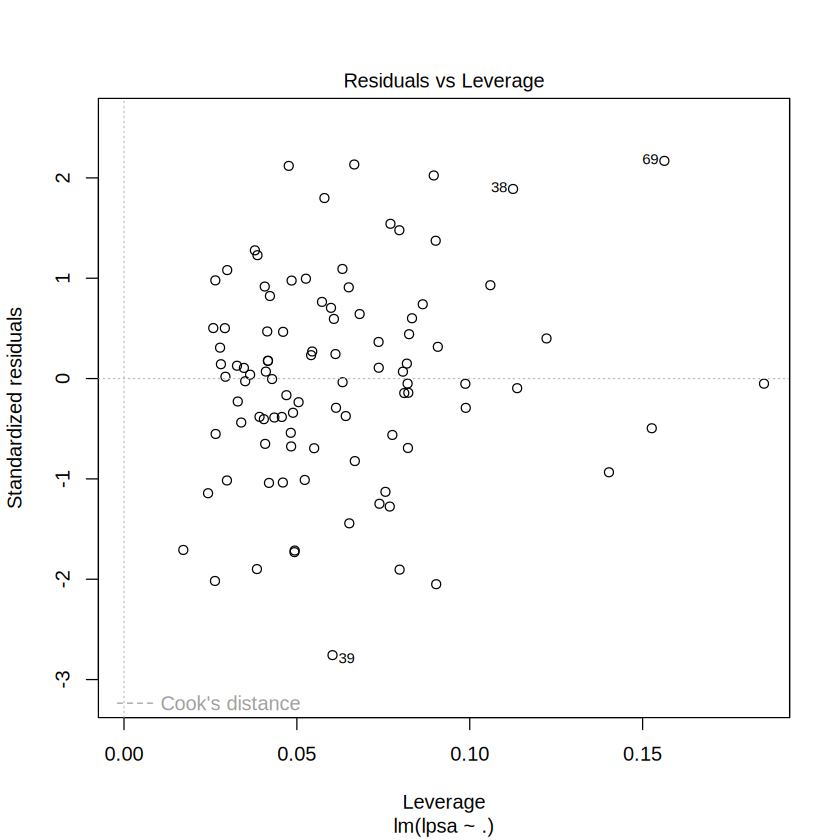

In [19]:
plot(r)

Eliminamos ahora la variable $\texttt{age}$

In [20]:
d <- d %>% select(-age)
r <- lm(lpsa~., data = d) #lpsa en función del resto de las variables
summary(r)


Call:
lm(formula = lpsa ~ ., data = d)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.85483 -0.35990 -0.01492  0.44467  1.53051 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  -0.3409     0.6936  -0.492  0.62420    
lcavol        0.5285     0.0745   7.094 2.63e-10 ***
lweight       0.5360     0.1964   2.729  0.00761 ** 
lbph          0.0786     0.0561   1.401  0.16454    
svi           0.7055     0.2080   3.392  0.00102 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.704 on 92 degrees of freedom
Multiple R-squared:  0.6436,	Adjusted R-squared:  0.6281 
F-statistic: 41.53 on 4 and 92 DF,  p-value: < 2.2e-16


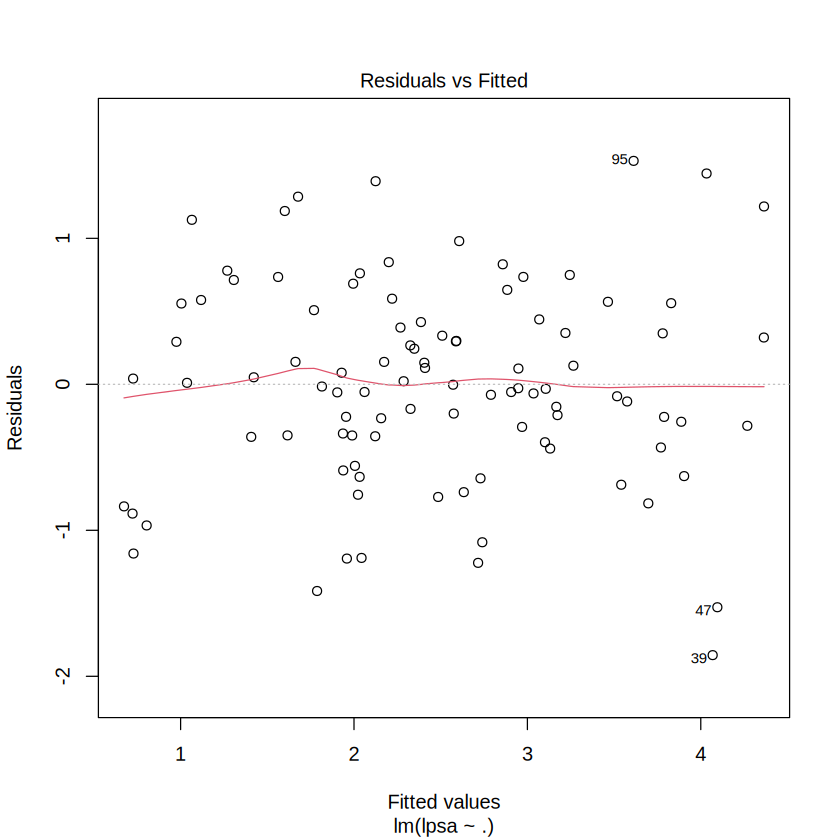

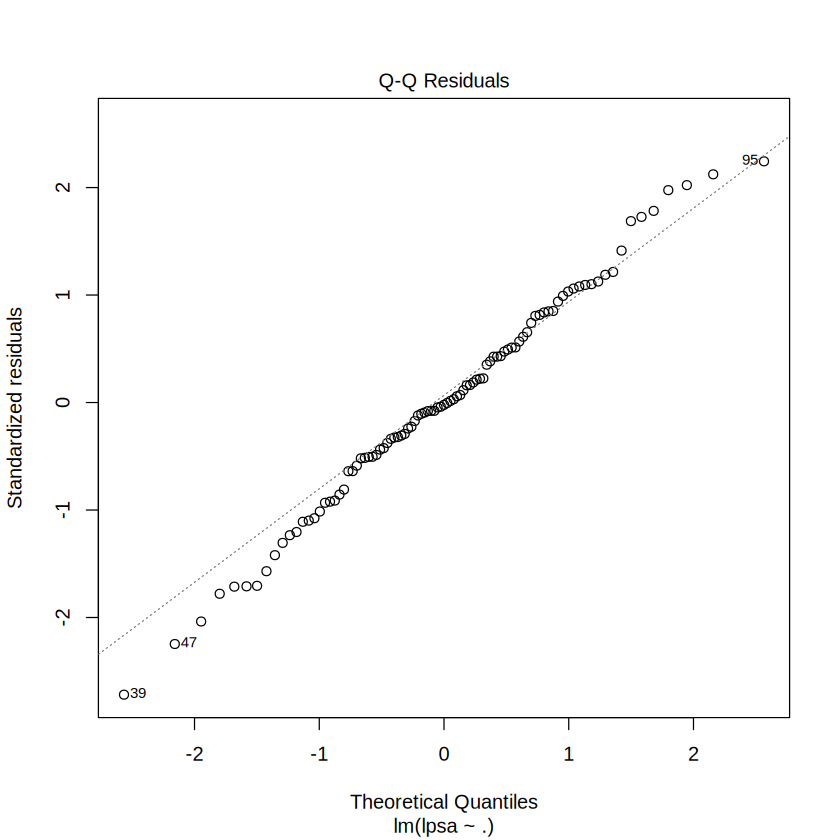

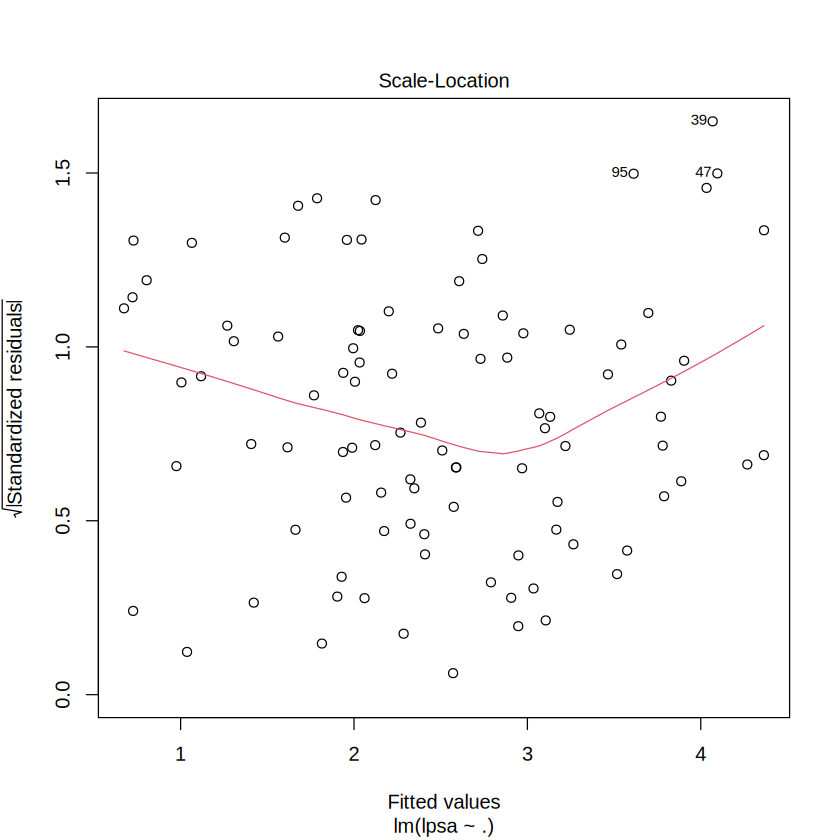

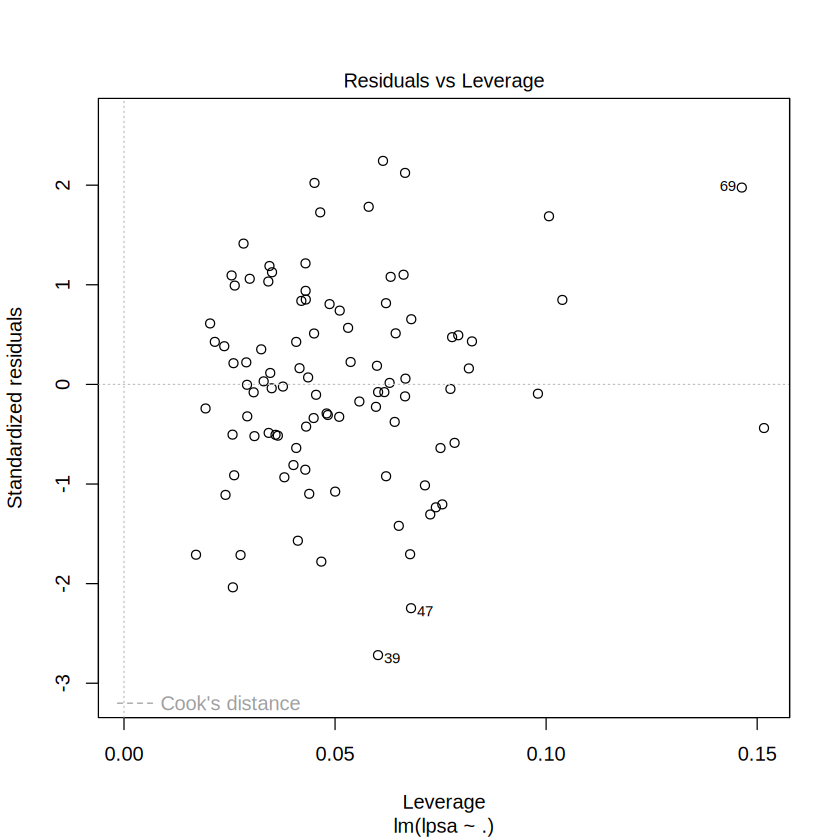

In [21]:
plot(r)

Finalmente eliminamos la variable $\texttt{lbph}$

In [22]:
d <- d %>% select(-lbph)
r <- lm(lpsa~., data = d) #lpsa en función del resto de las variables
summary(r)


Call:
lm(formula = lpsa ~ ., data = d)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.77745 -0.45004 -0.00254  0.44305  1.57574 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -0.77716    0.62300  -1.247 0.215367    
lcavol       0.52585    0.07486   7.024 3.49e-10 ***
lweight      0.66177    0.17564   3.768 0.000289 ***
svi          0.66567    0.20709   3.214 0.001798 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.7076 on 93 degrees of freedom
Multiple R-squared:  0.6359,	Adjusted R-squared:  0.6242 
F-statistic: 54.15 on 3 and 93 DF,  p-value: < 2.2e-16


### Diagnóstico

Una vez que hemos identificado a los predictores significativos diagnosticamos, visualmente, que los datos se ajusten al modelo generativo:  

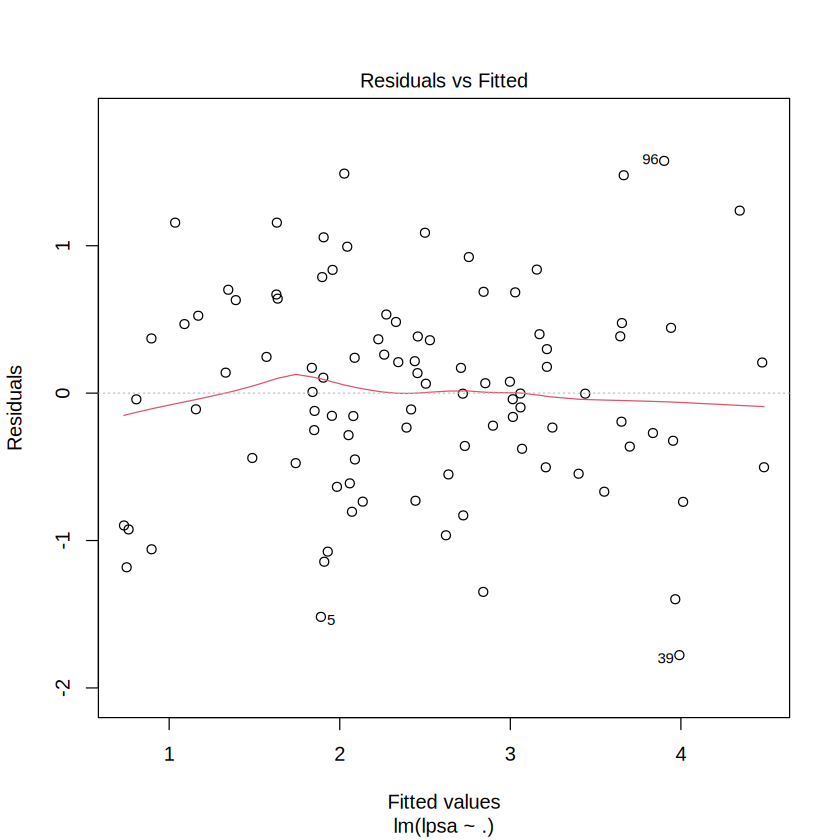

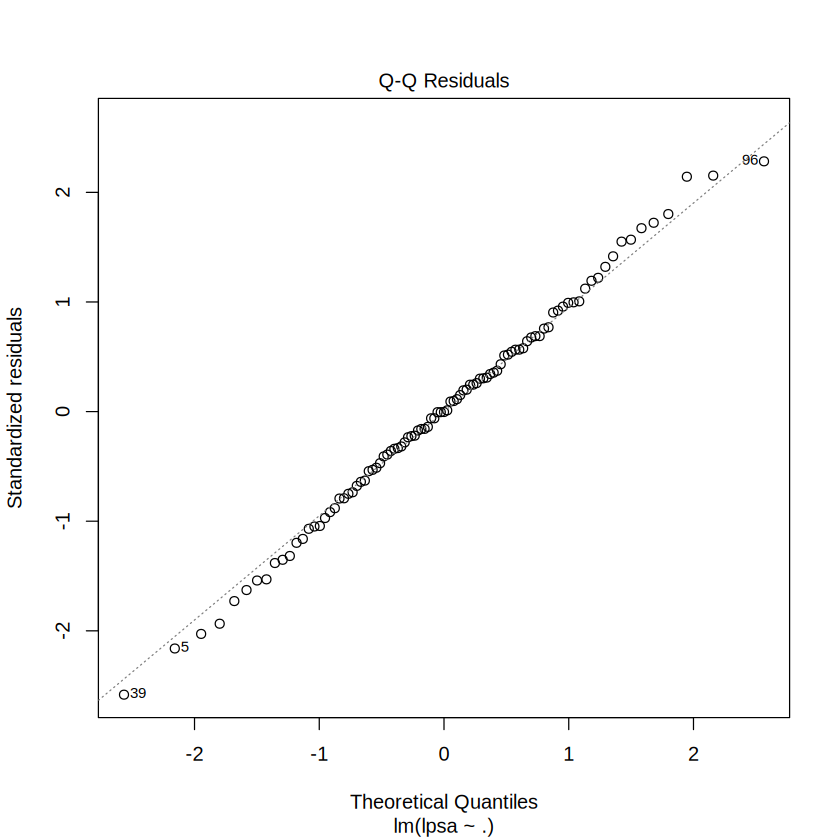

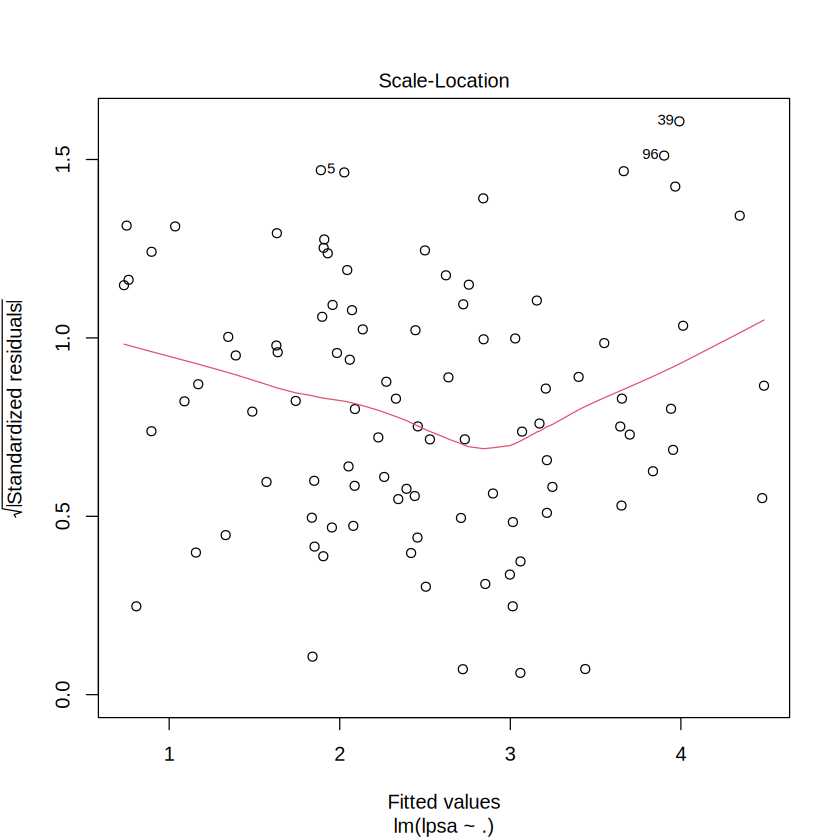

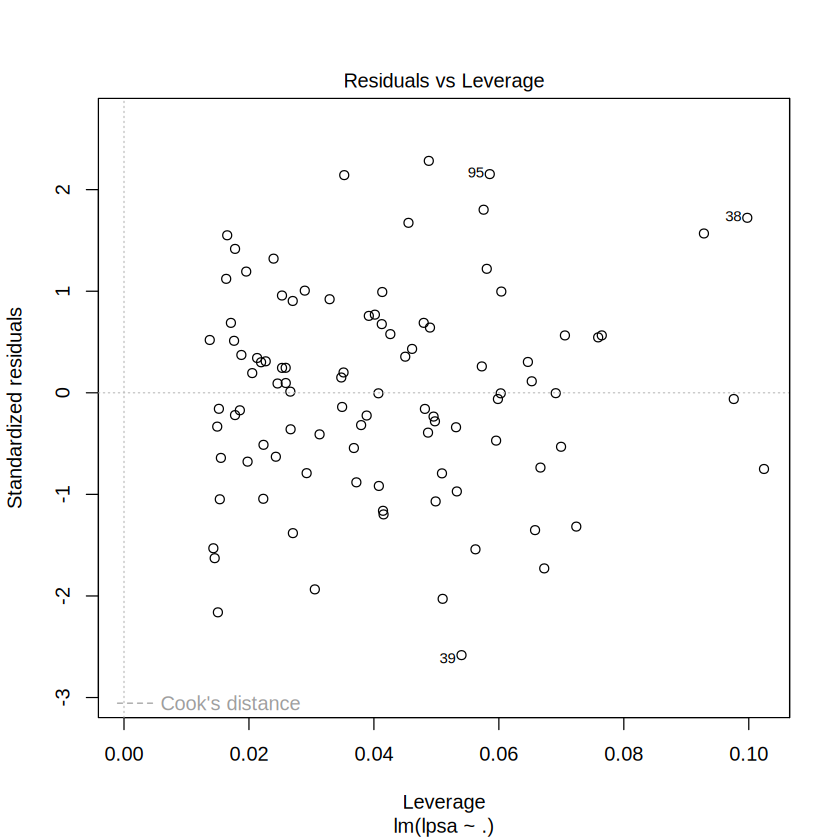

In [23]:
plot(r)

El diagnóstico para este caso permite validar la aplicación del modelo generativo y justifica las pruebas de hipótesis que seguimos para eliminar predictores no significativos.

Como hemos visto, este enfoque no siempre termina con la verificación de la aplicación del modelo generativo y puede ser necesaria la transformación de variables:

## Caso 2

El siguiente archivo es un resumen del total de ventas de una organización en diferentes ciudades. además del total de ventas, se tiene el registro de los montos destinados a la publicidad a través de tres canales diferentes: TV, radio y newspaper:

In [25]:
d <- read.csv("advertising.csv")
head(d)

,TV,radio,newspaper,sales
,<dbl>,<dbl>,<dbl>,<dbl>
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
6,8.7,48.9,75.0,7.2


Ajustamos un modelo lineal y eliminamos predictores no significativos:

In [26]:
r <- lm(sales~., data = d)
summary(r)


Call:
lm(formula = sales ~ ., data = d)

Residuals:
    Min      1Q  Median      3Q     Max 
-8.8277 -0.8908  0.2418  1.1893  2.8292 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  2.938889   0.311908   9.422   <2e-16 ***
TV           0.045765   0.001395  32.809   <2e-16 ***
radio        0.188530   0.008611  21.893   <2e-16 ***
newspaper   -0.001037   0.005871  -0.177     0.86    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.686 on 196 degrees of freedom
Multiple R-squared:  0.8972,	Adjusted R-squared:  0.8956 
F-statistic: 570.3 on 3 and 196 DF,  p-value: < 2.2e-16


In [27]:
d <- d %>% select(-newspaper)
r <- lm(sales~., data = d)
summary(r)


Call:
lm(formula = sales ~ ., data = d)

Residuals:
    Min      1Q  Median      3Q     Max 
-8.7977 -0.8752  0.2422  1.1708  2.8328 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  2.92110    0.29449   9.919   <2e-16 ***
TV           0.04575    0.00139  32.909   <2e-16 ***
radio        0.18799    0.00804  23.382   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.681 on 197 degrees of freedom
Multiple R-squared:  0.8972,	Adjusted R-squared:  0.8962 
F-statistic: 859.6 on 2 and 197 DF,  p-value: < 2.2e-16


### Diagnóstico

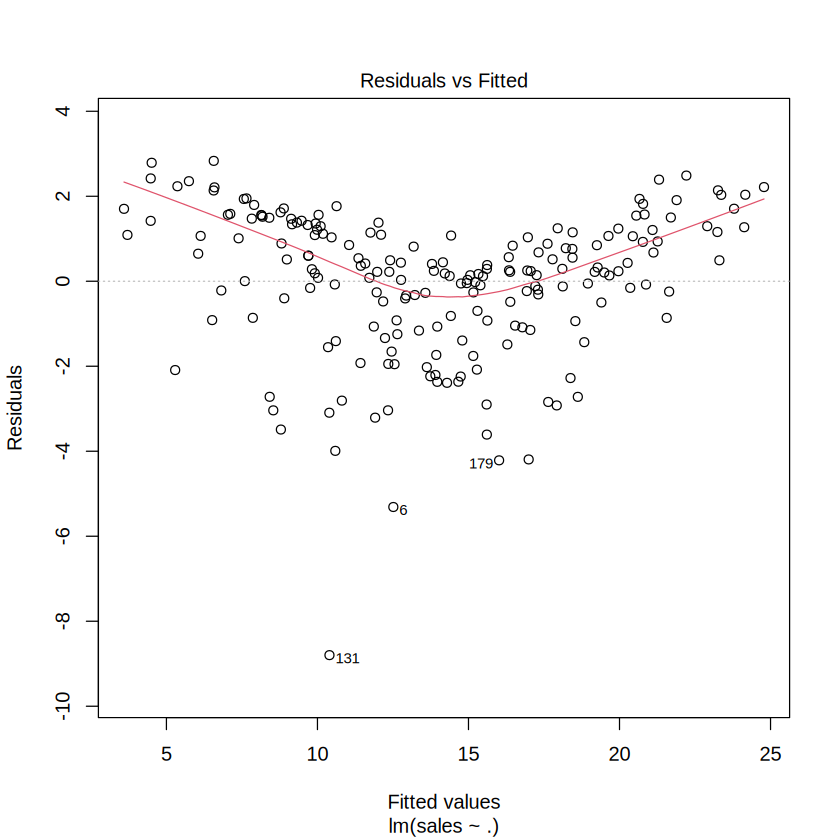

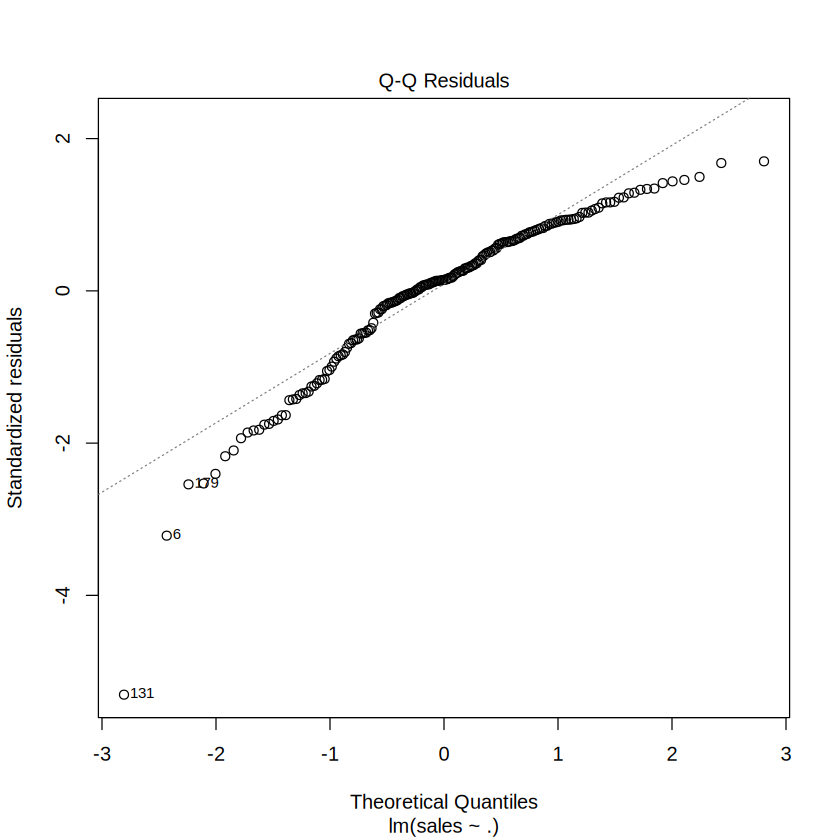

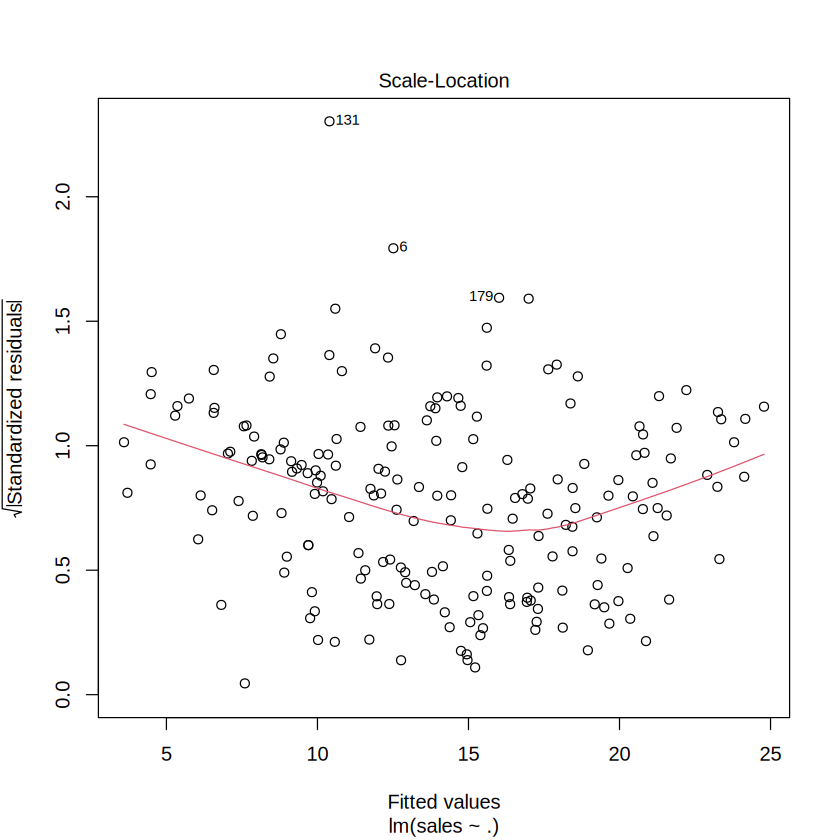

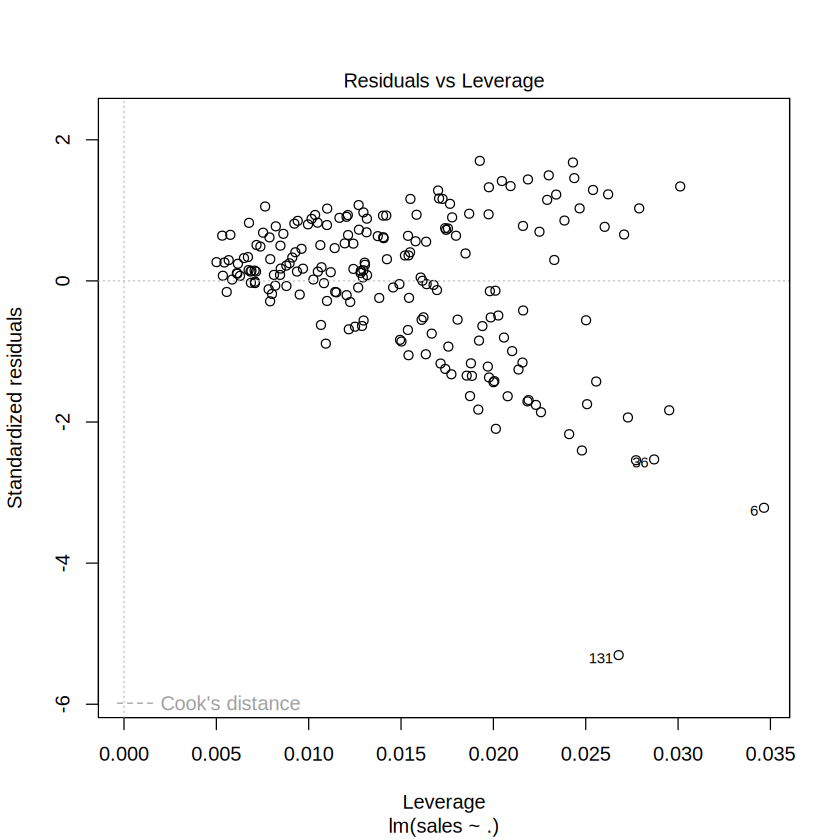

In [28]:
plot(r)

El diagnóstico muestra dos problemas:

* Los residuos muestran una estructura muy clara.
* Los residuos no parecen seguir a una distribución normal.

Dado que el modelo generativo no se cumple, no está justificado aplicar pruebas de hipótesis para identificar predictores significativos. Tampoco podemos construir intervalos de confianza para los parámetros del modelo lineal ni para las predicciones de la variable de respuesta.

**Es necesario transformar variables**.

Otra alternativa consiste en explorar las variables para identificar aquella cuya eliminación no disminuya de forma importante la $R^2$ o alguna otra medida de referencia, por ejemplo, el **criterio de información de Akaike**

El problema con estas estrategias es definir a cuánto equivale una **disminución importante**. Las regresiones ridge y lasso permiten dar la vuelta a este inconveniente.

# Regresión Ridge

La regresión ridge agrega un nuevo término a la suma de errores al cuadrado con el que se busca que el modelo ajustado tenga coeficientes con mínima magnitud:

$$R(a_0, a_1, \ldots, a_d) = \sum_i(a_0+a_1x_{i1}+\cdots+a_dx_{id}-y_i)^2+\lambda \sum_ja_j^2$$

En esta expresión, $\lambda$ es un parámetro que debe ajustar el usuario y que permite cumplir un compromiso entre un ajustar el modelo a los datos y exigir que tenga coeficientes pequeños.

Observa lo siguiente:

* Si $\lambda = 0$ tenemos la función de suma de errores al cuadrado, que se minimiza con los estimadores $a_i^{LS}$
* Si $\lambda \rightarrow \infty$, la única forma de minimizar $R$ es volviendo todos los coeficientes cero.
* Si un predictor no es importante, eliminarlo no tendrá mayor impacto en la primera sumatoria, de manera que podemos hacer cero su coeficiente y reducir la segunda sumatoria.

**En la práctica, podemos determinar el mejor valor de lambda mediante validación cruzada (o k-fold cross validation)**.

La implementación de la regresión ridge puede realizarse en $R$ a través de la librería $\texttt{glmnet}$


In [29]:
install.packages("glmnet")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘iterators’, ‘foreach’, ‘shape’, ‘RcppEigen’




In [30]:
library(glmnet)

Loading required package: Matrix

Loaded glmnet 5.1



In [32]:
d <- read.csv("prostate.data.csv", sep = "\t")
head(d)

,X,lcavol,lweight,age,lbph,svi,lcp,gleason,pgg45,lpsa,train
,<int>,<dbl>,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>,<int>,<dbl>,<lgl>
1,1,-0.5798185,2.769459,50,-1.386294,0,-1.386294,6,0,-0.4307829,TRUE
2,2,-0.9942523,3.319626,58,-1.386294,0,-1.386294,6,0,-0.1625189,TRUE
3,3,-0.5108256,2.691243,74,-1.386294,0,-1.386294,7,20,-0.1625189,TRUE
4,4,-1.2039728,3.282789,58,-1.386294,0,-1.386294,6,0,-0.1625189,TRUE
5,5,0.7514161,3.432373,62,-1.386294,0,-1.386294,6,0,0.3715636,TRUE
6,6,-1.0498221,3.228826,50,-1.386294,0,-1.386294,6,0,0.7654678,TRUE


In [33]:
d <- d %>% select(-X) #elimnamos la columna que indica si la observación pertenece al conjunto de entrenamiento

#separamos en datos de entrenamiento y prueba
d_train <- d %>% filter(train==T)
d_test <- d %>% filter(train==F)

d_train <- d_train %>% select(-train)
d_test <- d_test %>% select(-train)

In [34]:
#predictores
prdcts <- d_train %>% select(-lpsa)
summary(prdcts)

     lcavol           lweight           age             lbph         
 Min.   :-1.3471   Min.   :2.375   Min.   :41.00   Min.   :-1.38629  
 1st Qu.: 0.4883   1st Qu.:3.330   1st Qu.:61.00   1st Qu.:-1.38629  
 Median : 1.4679   Median :3.599   Median :65.00   Median :-0.05129  
 Mean   : 1.3135   Mean   :3.626   Mean   :64.75   Mean   : 0.07144  
 3rd Qu.: 2.3491   3rd Qu.:3.884   3rd Qu.:69.00   3rd Qu.: 1.54751  
 Max.   : 3.8210   Max.   :4.780   Max.   :79.00   Max.   : 2.32630  
      svi              lcp             gleason          pgg45       
 Min.   :0.0000   Min.   :-1.3863   Min.   :6.000   Min.   :  0.00  
 1st Qu.:0.0000   1st Qu.:-1.3863   1st Qu.:6.000   1st Qu.:  0.00  
 Median :0.0000   Median :-0.7985   Median :7.000   Median : 15.00  
 Mean   :0.2239   Mean   :-0.2142   Mean   :6.731   Mean   : 26.27  
 3rd Qu.:0.0000   3rd Qu.: 0.9948   3rd Qu.:7.000   3rd Qu.: 50.00  
 Max.   :1.0000   Max.   : 2.6568   Max.   :9.000   Max.   :100.00  

In [35]:
prdcts <- scale(prdcts)
summary(prdcts)

     lcavol           lweight              age                lbph         
 Min.   :-2.1411   Min.   :-2.62526   Min.   :-3.16524   Min.   :-0.99595  
 1st Qu.:-0.6641   1st Qu.:-0.62054   1st Qu.:-0.49936   1st Qu.:-0.99595  
 Median : 0.1242   Median :-0.05755   Median : 0.03382   Median :-0.08385  
 Mean   : 0.0000   Mean   : 0.00000   Mean   : 0.00000   Mean   : 0.00000  
 3rd Qu.: 0.8334   3rd Qu.: 0.54029   3rd Qu.: 0.56700   3rd Qu.: 1.00848  
 Max.   : 2.0180   Max.   : 2.42189   Max.   : 1.89994   Max.   : 1.54057  
      svi               lcp             gleason           pgg45        
 Min.   :-0.5331   Min.   :-0.8368   Min.   :-1.032   Min.   :-0.8965  
 1st Qu.:-0.5331   1st Qu.:-0.8368   1st Qu.:-1.032   1st Qu.:-0.8965  
 Median :-0.5331   Median :-0.4171   Median : 0.379   Median :-0.3846  
 Mean   : 0.0000   Mean   : 0.0000   Mean   : 0.000   Mean   : 0.0000  
 3rd Qu.:-0.5331   3rd Qu.: 0.8631   3rd Qu.: 0.379   3rd Qu.: 0.8099  
 Max.   : 1.8480   Max.   : 2.0496  

In [36]:
X <- as.matrix(prdcts)

#respuesta
Y <- as.numeric(d_train$lpsa)

In [37]:
fit <- glmnet(X,Y,alpha=0) #alpha permite elegir entre Ridge y Lasso (alpha=0 es Ridge)

Revisamos los resultados obtenidos con el ajuste

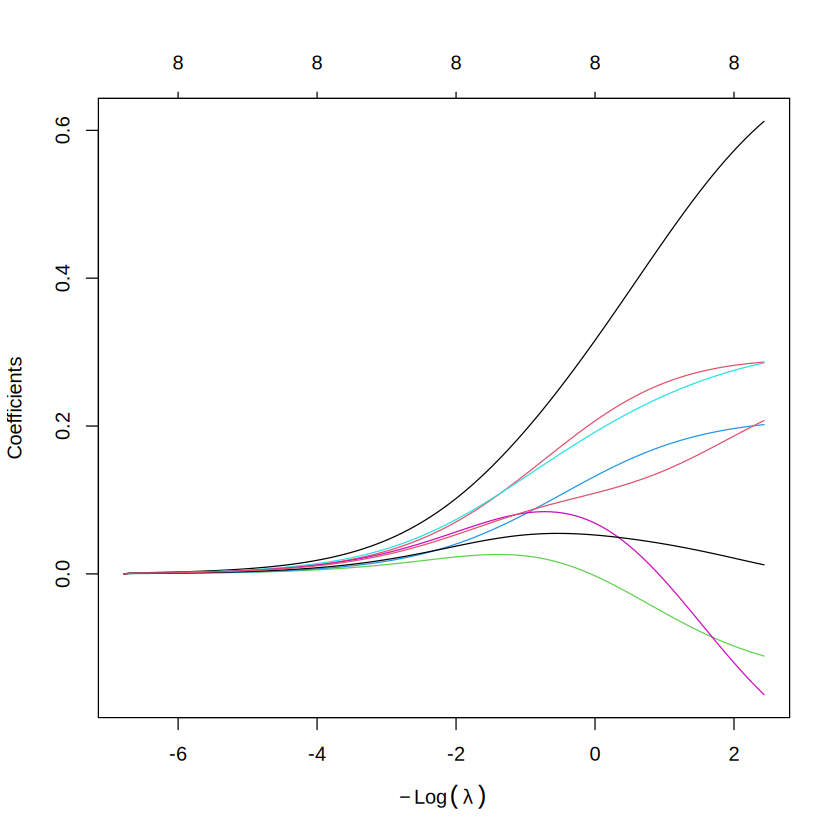

In [38]:
plot(fit)

Aplicamos validación cruzada para determinar el valor del parámetro $\lambda$

In [39]:
fit <- cv.glmnet(X,Y,alpha=0)

Identificamos la lambda con el mínimo error

In [40]:
fit$lambda.min

[1] 0.08788804

y revisamos los coeficientes obtenidos para ese valor

In [41]:
coef(fit, s = "lambda.min")

9 x 1 sparse Matrix of class "dgCMatrix"
             lambda.min
(Intercept)  2.45234509
lcavol       0.61217011
lweight      0.28654558
age         -0.11116955
lbph         0.20193434
svi          0.28529351
lcp         -0.16339970
gleason      0.01223217
pgg45        0.20739340

# Regresión Lasso

La regresión lasso se obtiene aplicando una pequeña modificación al funcional de la regresión ridge:

$$R(a_0, a_1, \ldots, a_d) = \sum_i(a_0+a_1x_{i1}+\cdots+a_dx_{id}-y_i)^2+\lambda \sum_j|a_j|$$

De manera general, esta estrategia permite identificar de forma más clara los coeficientes que se deben eliminar.

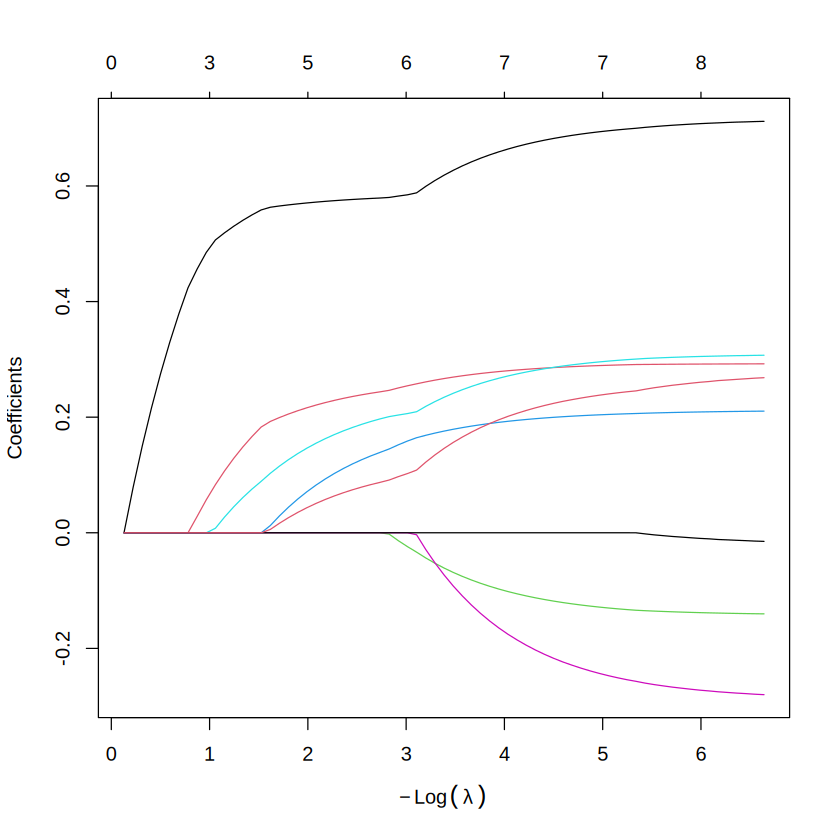

In [42]:
fit <- glmnet(X,Y,alpha=1) #alpha permite elegir entre Ridge y Lasso (alpha=1 es Lasso)
plot(fit)

In [43]:
#usamos validación cruzada para identificar el mejor valor de lambda
fit <- cv.glmnet(X,Y,alpha=1)

In [44]:
fit$lambda.min

[1] 0.01609

In [45]:
coef(fit, s = "lambda.min")

9 x 1 sparse Matrix of class "dgCMatrix"
            lambda.min
(Intercept)  2.4523451
lcavol       0.6682914
lweight      0.2816405
age         -0.1056170
lbph         0.1945168
svi          0.2748623
lcp         -0.1854286
gleason      .        
pgg45        0.2067548

## Segundo caso

In [46]:
d <- read.csv("advertising.csv")
head(d)

,TV,radio,newspaper,sales
,<dbl>,<dbl>,<dbl>,<dbl>
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
6,8.7,48.9,75.0,7.2


In [47]:
prdcts <- d %>% select(-sales)
prdcts <- scale(prdcts)
head(prdcts)

TV,radio,newspaper
0.96742460,0.9790656,1.7744925
-1.19437904,1.0800974,0.6679027
-1.51235985,1.5246374,1.7790842
0.05191939,1.2148065,1.2831850
0.39319551,-0.8395070,1.2785934
-1.61136487,1.7267010,2.0408088


In [48]:
summary(prdcts)

       TV               radio            newspaper      
 Min.   :-1.70455   Min.   :-1.56694   Min.   :-1.3892  
 1st Qu.:-0.84641   1st Qu.:-0.89507   1st Qu.:-0.8175  
 Median : 0.03154   Median :-0.02452   Median :-0.2206  
 Mean   : 0.00000   Mean   : 0.00000   Mean   : 0.0000  
 3rd Qu.: 0.83610   3rd Qu.: 0.89319   3rd Qu.: 0.6679  
 Max.   : 1.73966   Max.   : 1.77385   Max.   : 3.8316  

In [49]:
X <- as.matrix(prdcts)
Y <- as.numeric(d$sales)

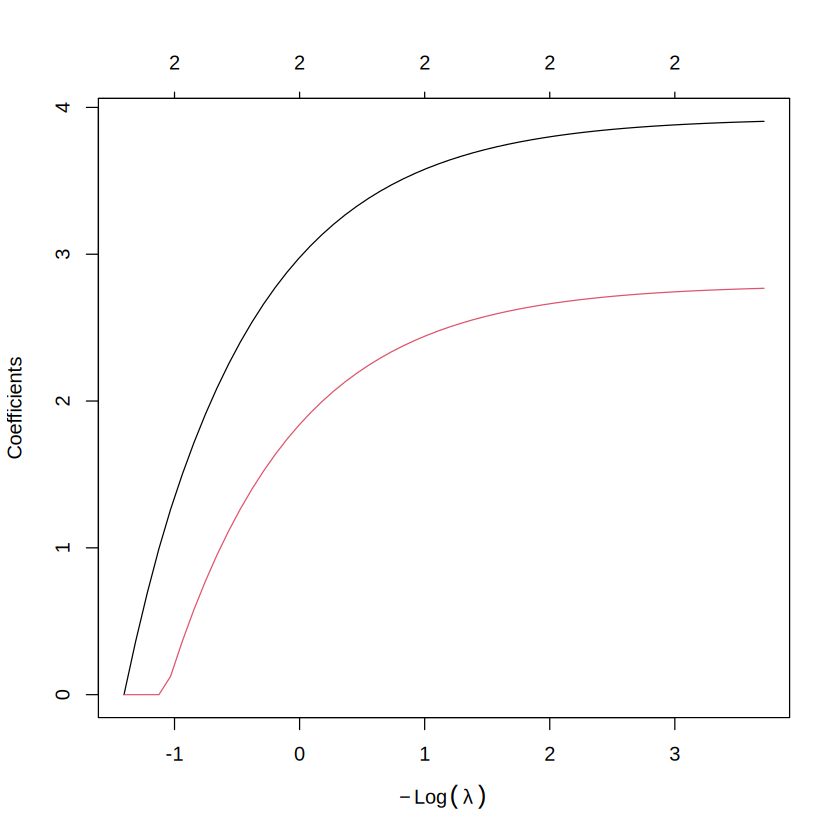

In [50]:
fit <- glmnet(X,Y,alpha=1) #alpha permite elegir entre Ridge y Lasso (alpha=1 es Lasso)
plot(fit)

In [51]:
fit <- cv.glmnet(X,Y,alpha=1)
fit$lambda.min

[1] 0.081796

In [52]:
coef(fit, s = "lambda.min")

4 x 1 sparse Matrix of class "dgCMatrix"
            lambda.min
(Intercept)  14.022500
TV            3.850504
radio         2.713374
newspaper     .       

Conclusiones/Reflexiones

**Análisis de la Práctica:**

Al aplicar y comparar las técnicas de regularización sobre nuestro conjunto de datos, podemos observar lo siguiente en el comportamiento del modelo:

1. **Estandarización de la información (`scale()`):** Los algoritmos son matemáticamente sensibles a la magnitud de los números. Si no "nivelamos la cancha" estandarizando los datos, la máquina no es perfecta y se deja llevar por las escalas originales, otorgando una falsa importancia a variables simplemente porque sus valores numéricos son más altos.

2. **Significancia de las variables (P-value):** Al ajustar el modelo lineal clásico, notamos que no todas las variables son predictores estadísticamente significativos (algunas superan ampliamente el umbral de 0.05). Esto nos indica que hay "ruido" o información que la computadora no puede interpretar como un aporte real a la predicción.

3. **Efecto de la regularización ($\lambda$):** Al introducir las penalizaciones, controlamos el *input* de información. Observamos que la regresión Ridge (penalización $L_2$) encoge los coeficientes para estabilizar el modelo cuando hay alta correlación, asumiendo que todos los predictores deben mantenerse vivos. En contraste, la regresión Lasso (penalización $L_1$) fuerza a que los coeficientes de las variables sin significancia caigan exactamente a cero.

**Conclusiones:**

* **La realidad de los datos:** La información en el mundo real rara vez viene detallada, depurada y lista para entrenar modelos perfectos. Nosotros estamos ahí precisamente para detectar las inconsistencias, preparar los datos y corregir el rumbo del algoritmo.

* **Modelos parsimoniosos con Lasso:** La regresión Lasso demostró ser una solución brillante cuando buscamos simplificar nuestros modelos. Al reducir a cero los coeficientes irrelevantes, realiza una selección automática de características muy efectiva.

* **Menos es más:** Aplicar machine learning no se trata de saturar al algoritmo con cada columna disponible en la base de datos. Como demostramos en este ejercicio, para evitar el sobreajuste (*overfitting*), la clave de un buen modelo está en aprender a identificar cuándo una variable nos quita más precisión y claridad de lo que realmente nos aporta.